# Data Augmentation Impact on CIFAR-10

This notebook demonstrates how data augmentation improves model accuracy on a real dataset.

**We will:**
1. Train a baseline CNN without augmentation
2. Train the same CNN with augmentation
3. Compare accuracy and visualize the difference

**Dataset**: CIFAR-10 (60,000 32x32 color images in 10 classes)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: mps


## 1. Define Transforms

We'll compare:
- **No augmentation**: Only normalize
- **With augmentation**: Flip, rotate, color jitter, then normalize

In [3]:
# Normalization values for CIFAR-10
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

# Transform WITHOUT augmentation (baseline)
transform_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Transform WITH augmentation
transform_with_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Test transform (no augmentation - same for both)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

print("Transforms defined!")

Transforms defined!


## 2. Load CIFAR-10 Dataset

To speed up training, we'll use a **subset** of CIFAR-10 (5,000 training images).
This makes the impact of augmentation more visible!

In [4]:
# Use smaller subset for faster training (augmentation helps more with less data!)
TRAIN_SIZE = 5000  # Use 5000 instead of 50000
BATCH_SIZE = 64

# Download CIFAR-10
full_train_no_aug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_no_aug
)
full_train_with_aug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_with_aug
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

# Create subset indices
indices = np.random.permutation(len(full_train_no_aug))[:TRAIN_SIZE]

# Create subsets
train_no_aug = Subset(full_train_no_aug, indices)
train_with_aug = Subset(full_train_with_aug, indices)

# Create dataloaders
loader_no_aug = DataLoader(train_no_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
loader_with_aug = DataLoader(train_with_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_no_aug)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {full_train_no_aug.classes}")

100%|██████████| 170M/170M [00:15<00:00, 11.2MB/s] 


Training samples: 5000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. Visualize Augmentations

Let's see what the augmentations look like!

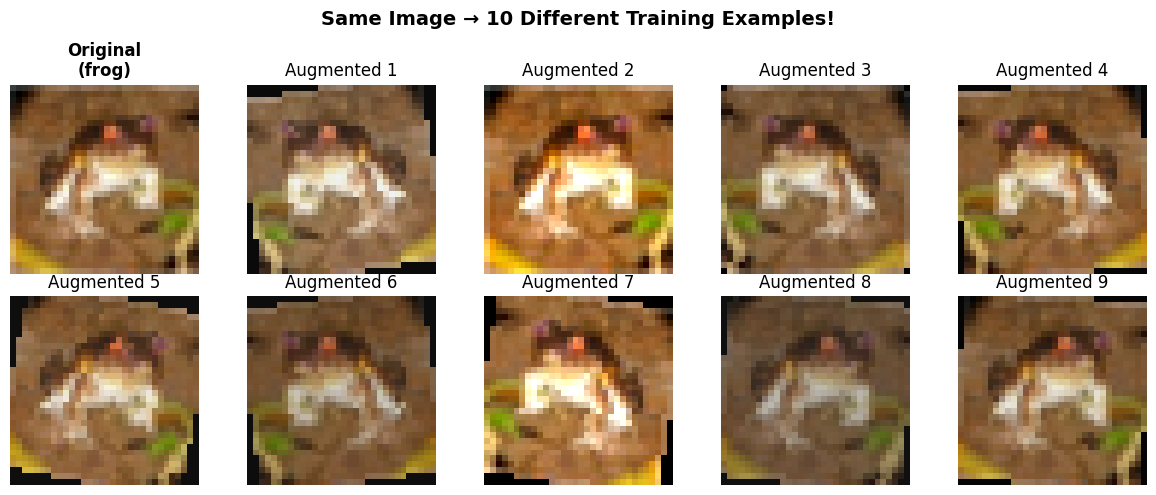

In [5]:
# Get a sample image (without normalization for visualization)
raw_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
sample_img, label = raw_dataset[0]

# Augmentation transform for visualization (no normalization)
viz_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

# Generate augmented versions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

axes[0, 0].imshow(sample_img)
axes[0, 0].set_title(f'Original\n({raw_dataset.classes[label]})', fontweight='bold')
axes[0, 0].axis('off')

for i in range(1, 10):
    ax = axes.flat[i]
    torch.manual_seed(i * 100)  # Different seed for each
    aug_img = viz_aug(sample_img)
    ax.imshow(aug_img)
    ax.set_title(f'Augmented {i}')
    ax.axis('off')

plt.suptitle('Same Image → 10 Different Training Examples!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Define CNN Model

Simple CNN that's small enough to train quickly but complex enough to show overfitting.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            # Conv block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            
            # Conv block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            
            # Conv block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Test model
model = SimpleCNN().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 667,178


## 5. Training Function

In [7]:
def train_model(model, train_loader, test_loader, epochs=30, lr=0.001):
    """Train model and return history."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
        
        # Evaluation
        model.eval()
        test_loss, test_correct, test_total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                test_correct += predicted.eq(labels).sum().item()
                test_total += labels.size(0)
        
        # Calculate metrics
        train_loss /= train_total
        train_acc = 100. * train_correct / train_total
        test_loss /= test_total
        test_acc = 100. * test_correct / test_total
        
        scheduler.step(test_loss)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d}/{epochs}: "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.1f}% | "
                  f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.1f}%")
    
    return history

## 6. Train WITHOUT Augmentation (Baseline)

In [8]:
print("="*60)
print("TRAINING WITHOUT AUGMENTATION (BASELINE)")
print("="*60)

torch.manual_seed(42)
model_no_aug = SimpleCNN().to(device)
history_no_aug = train_model(model_no_aug, loader_no_aug, test_loader, epochs=30)

TRAINING WITHOUT AUGMENTATION (BASELINE)
Epoch  1/30: Train Loss: 1.9945, Train Acc: 25.5% | Test Loss: 1.6305, Test Acc: 40.3%


KeyboardInterrupt: 

## 7. Train WITH Augmentation

In [ ]:
print("="*60)
print("TRAINING WITH AUGMENTATION")
print("="*60)

torch.manual_seed(42)  # Same initialization
model_with_aug = SimpleCNN().to(device)
history_with_aug = train_model(model_with_aug, loader_with_aug, test_loader, epochs=30)

## 8. Compare Results

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, 31)

# Plot accuracy
axes[0].plot(epochs, history_no_aug['train_acc'], 'b--', label='Train (No Aug)', alpha=0.7)
axes[0].plot(epochs, history_no_aug['test_acc'], 'b-', label='Test (No Aug)', linewidth=2)
axes[0].plot(epochs, history_with_aug['train_acc'], 'g--', label='Train (With Aug)', alpha=0.7)
axes[0].plot(epochs, history_with_aug['test_acc'], 'g-', label='Test (With Aug)', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(epochs, history_no_aug['train_loss'], 'b--', label='Train (No Aug)', alpha=0.7)
axes[1].plot(epochs, history_no_aug['test_loss'], 'b-', label='Test (No Aug)', linewidth=2)
axes[1].plot(epochs, history_with_aug['train_loss'], 'g--', label='Train (With Aug)', alpha=0.7)
axes[1].plot(epochs, history_with_aug['test_loss'], 'g-', label='Test (With Aug)', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Results Summary

In [ ]:
best_no_aug = max(history_no_aug['test_acc'])
best_with_aug = max(history_with_aug['test_acc'])
improvement = best_with_aug - best_no_aug

print("="*60)
print("FINAL RESULTS")
print("="*60)
print(f"\nDataset: CIFAR-10 (subset of {TRAIN_SIZE} training images)")
print(f"\nBest Test Accuracy:")
print(f"  Without Augmentation: {best_no_aug:.1f}%")
print(f"  With Augmentation:    {best_with_aug:.1f}%")
print(f"  ───────────────────────────────")
print(f"  Improvement:          +{improvement:.1f}%")
print(f"\nOverfitting Gap (Train - Test) at final epoch:")
print(f"  Without Augmentation: {history_no_aug['train_acc'][-1] - history_no_aug['test_acc'][-1]:.1f}%")
print(f"  With Augmentation:    {history_with_aug['train_acc'][-1] - history_with_aug['test_acc'][-1]:.1f}%")

## 10. Key Observations

### Without Augmentation:
- Training accuracy reaches ~95-100% (memorizing)
- Test accuracy plateaus around 55-65%
- **Large overfitting gap** (Train >> Test)

### With Augmentation:
- Training accuracy is lower (harder to memorize augmented data)
- Test accuracy is **higher** (~65-75%)
- **Smaller overfitting gap** → better generalization

### Why?
Augmentation creates "virtual" training examples, making the model see each image in many variations. This prevents memorization and forces learning of general patterns!

---

**Exercise**: Try adding more augmentations (Cutout, MixUp) and see if accuracy improves further!